<a href="https://colab.research.google.com/github/aminsiddik2810/data-science-2026/blob/https%2Fgithub.com%2Faminsiddik2810%2Fdata-science-2026.git/Pertemuan4_AminSiddikRangkuti_220401010124.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")

In [23]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

df["species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [24]:
print("Shape:", df.shape)
print("\nTipe data:")
print(df.dtypes)

print("\nData awal:")
display(df.head())

print("\nStatistik deskriptif:")
display(df.describe().round(3))

Shape: (150, 5)

Tipe data:
sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

Data awal:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Statistik deskriptif:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [25]:
print("Missing value:")
print(df.isnull().sum())

print("\nJumlah duplikat:")
print(df.duplicated().sum())

Missing value:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Jumlah duplikat:
1


In [26]:
num_cols = df.select_dtypes(include="number").columns

for col_name in num_cols:
    col = df[col_name]
    print(f"\n=== {col_name} ===")
    print(f"Mean     : {col.mean():.3f}")
    print(f"Median   : {col.median():.3f}")
    print(f"Modus    : {col.mode().values}")
    print(f"Varians  : {col.var():.3f}")
    print(f"Std Dev  : {col.std():.3f}")
    print(f"Skewness : {col.skew():.3f}")
    print(f"Kurtosis : {col.kurt():.3f}")


=== sepal_length ===
Mean     : 5.843
Median   : 5.800
Modus    : [5.]
Varians  : 0.686
Std Dev  : 0.828
Skewness : 0.315
Kurtosis : -0.552

=== sepal_width ===
Mean     : 3.057
Median   : 3.000
Modus    : [3.]
Varians  : 0.190
Std Dev  : 0.436
Skewness : 0.319
Kurtosis : 0.228

=== petal_length ===
Mean     : 3.758
Median   : 4.350
Modus    : [1.4 1.5]
Varians  : 3.116
Std Dev  : 1.765
Skewness : -0.275
Kurtosis : -1.402

=== petal_width ===
Mean     : 1.199
Median   : 1.300
Modus    : [0.2]
Varians  : 0.581
Std Dev  : 0.762
Skewness : -0.103
Kurtosis : -1.341


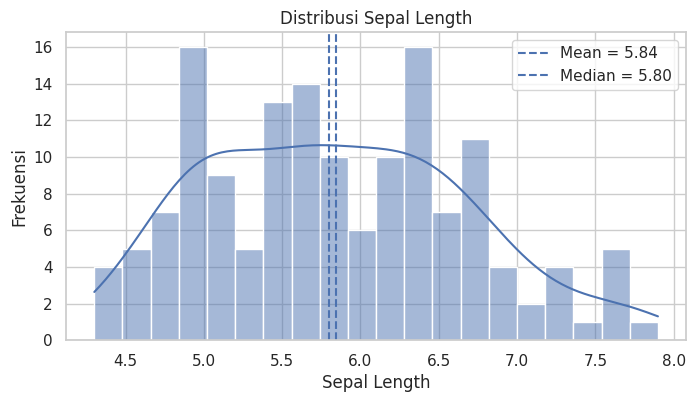

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(df["sepal_length"], kde=True, bins=20, ax=ax)

ax.axvline(df["sepal_length"].mean(), linestyle="--",
           label=f"Mean = {df['sepal_length'].mean():.2f}")

ax.axvline(df["sepal_length"].median(), linestyle="--",
           label=f"Median = {df['sepal_length'].median():.2f}")

ax.set_title("Distribusi Sepal Length")
ax.set_xlabel("Sepal Length")
ax.set_ylabel("Frekuensi")
ax.legend()

plt.show()

In [28]:
skew_sl = df["sepal_length"].skew()

print(f"Skewness sepal_length: {skew_sl:.3f}")

if skew_sl > 0.5:
    print("Distribusi miring ke kanan / right-skewed.")
elif skew_sl < -0.5:
    print("Distribusi miring ke kiri / left-skewed.")
else:
    print("Distribusi relatif simetris / mendekati normal.")

Skewness sepal_length: 0.315
Distribusi relatif simetris / mendekati normal.


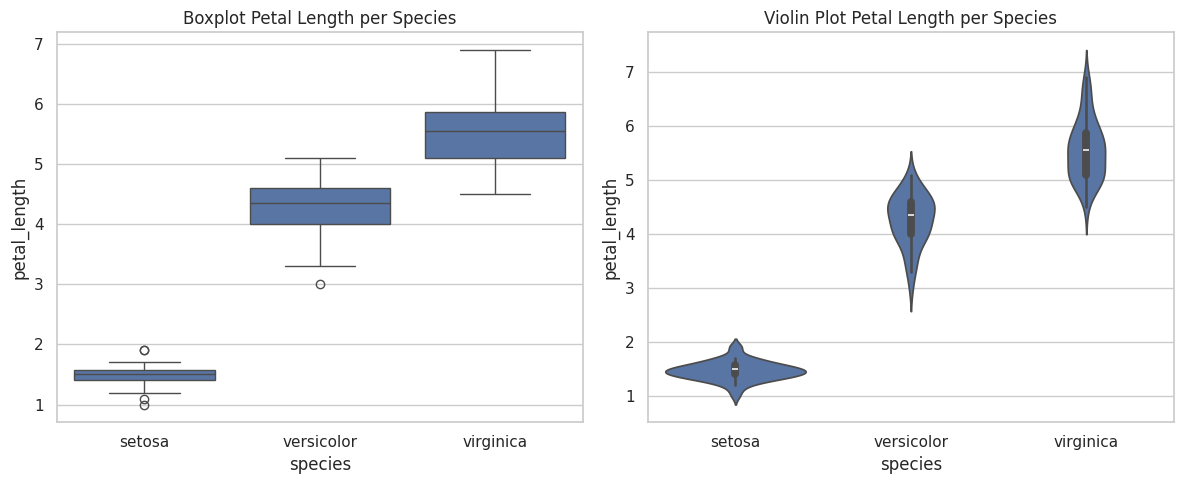

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="species", y="petal_length", ax=axes[0])
axes[0].set_title("Boxplot Petal Length per Species")

sns.violinplot(data=df, x="species", y="petal_length", inner="box", ax=axes[1])
axes[1].set_title("Violin Plot Petal Length per Species")

plt.tight_layout()
plt.show()

In [30]:
summary_species = df.groupby("species", observed=True)["petal_length"].agg(
    ["min", "max", "mean", "median", "std"]
).round(3)

display(summary_species)

print("Petal_length terbesar :", summary_species["mean"].idxmax())
print("Petal_length terkecil :", summary_species["mean"].idxmin())
print("Penyebaran terbesar   :", summary_species["std"].idxmax())

,min,max,mean,median,std
species,,,,,
setosa,1.0,1.9,1.462,1.50,0.174
versicolor,3.0,5.1,4.260,4.35,0.470
virginica,4.5,6.9,5.552,5.55,0.552


Petal_length terbesar : virginica
Petal_length terkecil : setosa
Penyebaran terbesar   : virginica


In [31]:
corr = df[num_cols].corr(method="pearson")

display(corr.round(3))

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000,-0.118,0.872,0.818
sepal_width,-0.118,1.000,-0.428,-0.366
petal_length,0.872,-0.428,1.000,0.963
petal_width,0.818,-0.366,0.963,1.000


In [32]:
mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)

max_pair = corr_masked.stack().idxmax()
min_pair = corr_masked.stack().idxmin()

print(f"Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}")
print(f"Korelasi terendah : {min_pair} = {corr.loc[min_pair]:.3f}")

Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963
Korelasi terendah : ('petal_length', 'sepal_width') = -0.428


In [33]:
x = df["petal_length"]
y = df["petal_width"]

r, p_r = stats.pearsonr(x, y)
rho, p_s = stats.spearmanr(x, y)

print(f"Pearson r  = {r:.4f}, p-value = {p_r:.6f}")
print(f"Spearman ρ = {rho:.4f}, p-value = {p_s:.6f}")

Pearson r  = 0.9629, p-value = 0.000000
Spearman ρ = 0.9377, p-value = 0.000000


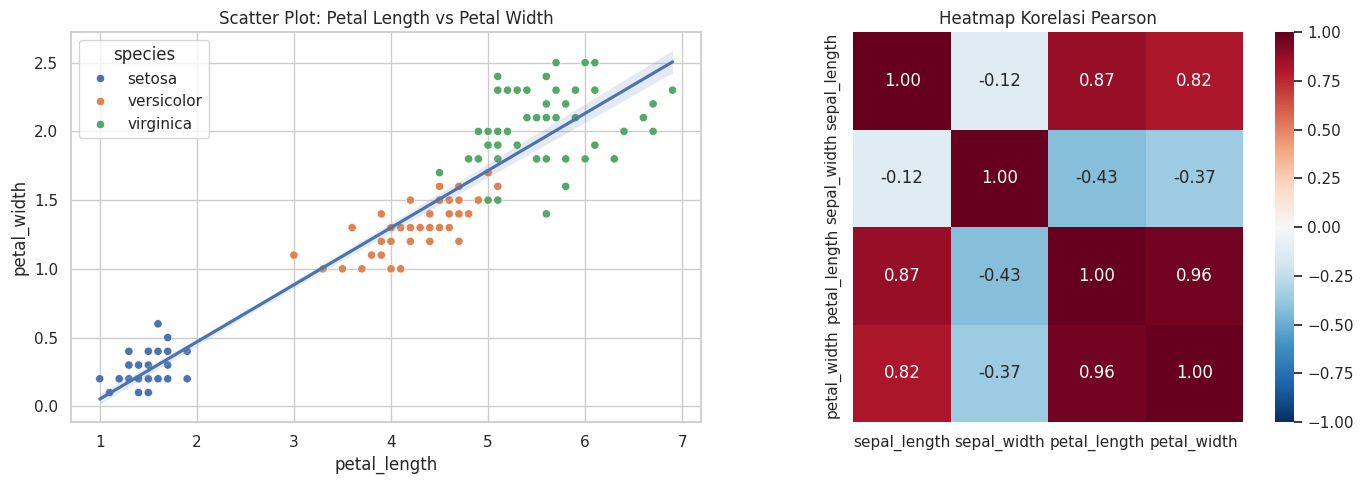

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=df,
    x="petal_length",
    y="petal_width",
    hue="species",
    ax=axes[0]
)

sns.regplot(
    data=df,
    x="petal_length",
    y="petal_width",
    scatter=False,
    ax=axes[0]
)

axes[0].set_title("Scatter Plot: Petal Length vs Petal Width")

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1]
)

axes[1].set_title("Heatmap Korelasi Pearson")

plt.tight_layout()
plt.show()

In [35]:
print("""
Interpretasi Akhir:

Dataset Iris terdiri dari 150 baris dan 5 kolom.
Empat kolom merupakan data numerik, yaitu sepal_length, sepal_width,
petal_length, dan petal_width. Satu kolom merupakan data kategorik, yaitu species.

Statistik deskriptif menunjukkan ukuran pemusatan, penyebaran,
skewness, dan kurtosis dari setiap variabel numerik.

Histogram sepal_length menunjukkan distribusi yang relatif simetris.

Boxplot dan violin plot menunjukkan bahwa setosa memiliki petal_length paling kecil,
sedangkan virginica memiliki petal_length paling besar.

Matriks korelasi Pearson menunjukkan hubungan antar variabel numerik.
Petal_length dan petal_width memiliki korelasi positif yang sangat kuat.

Scatter plot memperlihatkan semakin besar petal_length, maka petal_width
cenderung semakin besar.

Heatmap membantu membaca korelasi antar variabel secara visual.
""")


Interpretasi Akhir:

Dataset Iris terdiri dari 150 baris dan 5 kolom.
Empat kolom merupakan data numerik, yaitu sepal_length, sepal_width,
petal_length, dan petal_width. Satu kolom merupakan data kategorik, yaitu species.

Statistik deskriptif menunjukkan ukuran pemusatan, penyebaran,
skewness, dan kurtosis dari setiap variabel numerik.

Histogram sepal_length menunjukkan distribusi yang relatif simetris.

Boxplot dan violin plot menunjukkan bahwa setosa memiliki petal_length paling kecil,
sedangkan virginica memiliki petal_length paling besar.

Matriks korelasi Pearson menunjukkan hubungan antar variabel numerik.
Petal_length dan petal_width memiliki korelasi positif yang sangat kuat.

Scatter plot memperlihatkan semakin besar petal_length, maka petal_width
cenderung semakin besar.

Heatmap membantu membaca korelasi antar variabel secara visual.

